# Daily Curve Comparison

This notebook compares one-day closed-loop state curves on **July 9** for DMPC, SMPC, RMPC, DRMPC, TMPC, UA-TMPC, and Perfect. The figure style follows the paper-style daily SOC and temperature plots: actual state, nominal state, physical bounds, tightened feasible region, and pre-correction constraint violations.

In [2]:
from pathlib import Path
import pickle
import sys
import time
import warnings
from functools import cached_property
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

project_root = Path.cwd()
if project_root.name == "UATMPC":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from UATMPC import MPCConfig, Paths, PhysicalParams
from UATMPC.experiment import ExperimentRunner


paths = Paths.from_root(project_root)
config = MPCConfig()
params = PhysicalParams()
class Building2Params(PhysicalParams):
    @cached_property
    def tau_min(self):
        return np.concatenate([14 * np.ones(8 * 4), 14 * np.ones(14 * 4), 14 * np.ones(6 * 4)])
    @cached_property
    def tau_max(self):
        return np.concatenate([24 * np.ones(8 * 4), 24 * np.ones(14 * 4), 24 * np.ones(6 * 4)])

# change to the winter setting:
# params = Building2Params(
#     tau_ref=20,
#     p_hvac_max=20,
# )

runner = ExperimentRunner(paths, config, params).setup()

paths.results_dir.mkdir(parents=True, exist_ok=True)
paths.results_dir

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results')

## Settings

The method names below map the paper labels to the implementation names used by `ExperimentRunner`. The default `ww = 0.1` matches the monthly comparison notebook.

In [5]:
date = (7, 9)
ww = 0.1
# Regenerate every method and overwrite this date's cached curves and summary.
force_rerun = False
# Regenerate only these cached methods. Set to [] to reuse every cached result.
rerun_methods = []

curve_cache = paths.results_dir / f"daily_curve_{date[0]:02d}_{date[1]:02d}_ww_{ww:g}.pkl"
summary_csv = paths.results_dir / f"daily_curve_{date[0]:02d}_{date[1]:02d}_ww_{ww:g}_summary.csv"
figure_path = paths.results_dir / f"daily_curve_{date[0]:02d}_{date[1]:02d}_ww_{ww:g}.png"

method_specs = [
    ("DMPC", "standard"),
    ("SMPC", "scenario"),
    ("RMPC", "robust"),
    ("DRMPC", "dr"),
    ("TMPC", "soft_tube_ess"),
    ("UA-TMPC", "soft_ua_tube"),
]

unknown_rerun_methods = set(rerun_methods) - {label for label, _ in method_specs}
if unknown_rerun_methods:
    raise ValueError(f"Unknown rerun methods: {sorted(unknown_rerun_methods)}")

{
    "date": date,
    "ww": ww,
    "methods": [label for label, _ in method_specs],
    "rerun_methods": rerun_methods,
    "curve_cache": curve_cache,
    "summary_csv": summary_csv,
    "figure_path": figure_path,
}

{'date': (7, 9),
 'ww': 0.1,
 'methods': ['DMPC', 'SMPC', 'RMPC', 'DRMPC', 'TMPC', 'UA-TMPC'],
 'rerun_methods': [],
 'curve_cache': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/daily_curve_07_09_ww_0.1.pkl'),
 'summary_csv': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/daily_curve_07_09_ww_0.1_summary.csv'),
 'figure_path': PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/daily_curve_07_09_ww_0.1.png')}

## Run Or Load Results

The next cell runs each method once and saves the full curve dictionaries. One method can take several minutes depending on the solver license and machine speed.

In [6]:
def run_method(date, method):
    if method == "standard":
        return runner.run_standard_day(date)
    if method == "scenario":
        return runner.run_scenario_day(date)
    if method == "robust":
        return runner.run_robust_day(date)
    if method == "dr":
        return runner.run_dr_day(date)
    if method == "soft_tube_ess":
        return runner.run_tube_day(date, soft=True, ww=ww, alphas=(0.0, 0.0, 1.0, 0.0))
    if method == "soft_ua_tube":
        return runner.run_ua_tube_day(date, soft=True, ww=ww)
    if method == "ground_truth":
        return runner.run_ground_truth_day(date)
    raise ValueError(f"Unknown method: {method}")


def summarize_result(label, result, status="ok", error=""):
    month, day = date
    return {
        "date_month": month,
        "date_day": day,
        "label": label,
        "method": result.get("method", ""),
        "runtime": result.get("runtime", np.nan),
        "total_cost": result.get("total_cost", np.nan),
        "operational_cost": result.get("operational_cost", np.nan),
        "total_penalty": result.get("total_penalty", np.nan),
        "status": status,
        "error": error,
    }


if curve_cache.exists() and not force_rerun:
    with curve_cache.open("rb") as f:
        daily_results = pickle.load(f)
    print(f"Loaded cached curves from {curve_cache}")
else:
    daily_results = {}

for label, method in method_specs:
    should_rerun = force_rerun or label in rerun_methods or label not in daily_results
    if not should_rerun:
        continue

    print(f"Running {label} ({method}) on {date} ...")
    started_at = time.time()
    try:
        result = run_method(date, method)
        result["label"] = label
        result["status"] = "ok"
        result["error"] = ""
        daily_results[label] = result
        print(f"  ok: total_cost={result['total_cost']:.2f}, runtime={result['runtime']:.1f}s")
    except Exception as exc:
        daily_results[label] = {
            "label": label,
            "method": method,
            "status": "failed",
            "error": repr(exc),
            "runtime": time.time() - started_at,
        }
        print(f"  failed: {exc!r}")
    finally:
        with curve_cache.open("wb") as f:
            pickle.dump(daily_results, f)

summary_df = pd.DataFrame(
    [
        summarize_result(label, daily_results.get(label, {}), daily_results.get(label, {}).get("status", "missing"), daily_results.get(label, {}).get("error", ""))
        for label, _ in method_specs
    ]
)
summary_df.to_csv(summary_csv, index=False)
summary_df

Loaded cached curves from /Users/liqi/Desktop/UATMPC codes/UATMPC/results/daily_curve_07_09_ww_0.1.pkl


,date_month,date_day,label,method,runtime,total_cost,operational_cost,total_penalty,status,error
0,7,9,DMPC,standard,58.811583,1216.460794,917.718911,298.741883,ok,
1,7,9,SMPC,scenario,166.743610,1189.822461,941.374502,248.447959,ok,
2,7,9,RMPC,robust,57.143692,1132.582856,1132.582856,0.000000,ok,
3,7,9,DRMPC,dr,265.467299,1220.046899,922.613982,297.432917,ok,
4,7,9,TMPC,soft_tube,89.391742,1138.402606,1104.322591,34.080015,ok,
5,7,9,UA-TMPC,soft_ua_tube,140.864613,990.118091,990.118091,0.000000,ok,


## Run Perfect

Run the full-day ground-truth optimizer separately and merge it into `daily_results`, so existing UA-TMPC results can be reused without rerunning every method.

In [ ]:
rerun_perfect = False

if rerun_perfect or daily_results.get("Perfect", {}).get("status") != "ok":
    print(f"Running Perfect (ground_truth) on {date} ...")
    started_at = time.time()
    try:
        perfect_result = runner.run_ground_truth_day(date)
        perfect_result["label"] = "Perfect"
        perfect_result["status"] = "ok"
        perfect_result["error"] = ""
        daily_results["Perfect"] = perfect_result
        print(f"  ok: total_cost={perfect_result['total_cost']:.2f}, runtime={perfect_result['runtime']:.1f}s")
    except Exception as exc:
        daily_results["Perfect"] = {
            "label": "Perfect",
            "method": "ground_truth",
            "status": "failed",
            "error": repr(exc),
            "runtime": time.time() - started_at,
        }
        print(f"  failed: {exc!r}")

    with curve_cache.open("wb") as f:
        pickle.dump(daily_results, f)
else:
    print("Loaded existing Perfect result from daily_results.")

summary_df = pd.DataFrame(
    [
        summarize_result(
            label,
            daily_results.get(label, {}),
            daily_results.get(label, {}).get("status", "missing"),
            daily_results.get(label, {}).get("error", ""),
        )
        for label, _ in method_specs
    ]
)
summary_df.to_csv(summary_csv, index=False)
summary_df

Running Perfect (ground_truth) on (7, 9) ...
  ok: total_cost=736.62, runtime=0.3s


,date_month,date_day,label,method,runtime,total_cost,operational_cost,total_penalty,status,error
0,7,9,DMPC,standard,58.811583,1216.460794,917.718911,298.741883,ok,
1,7,9,SMPC,scenario,166.743610,1189.822461,941.374502,248.447959,ok,
2,7,9,RMPC,robust,57.143692,1132.582856,1132.582856,0.000000,ok,
3,7,9,DRMPC,dr,265.467299,1220.046899,922.613982,297.432917,ok,
4,7,9,TMPC,soft_tube,89.391742,1138.402606,1104.322591,34.080015,ok,
5,7,9,UA-TMPC,soft_ua_tube,140.864613,990.118091,990.118091,0.000000,ok,


In [7]:
summary_df = summary_df[summary_df["label"] != "Perfect"]
summary_df.to_csv(summary_csv, index=False)
summary_df

,date_month,date_day,label,method,runtime,total_cost,operational_cost,total_penalty,status,error
0,7,9,DMPC,standard,58.811583,1216.460794,917.718911,298.741883,ok,
1,7,9,SMPC,scenario,166.743610,1189.822461,941.374502,248.447959,ok,
2,7,9,RMPC,robust,57.143692,1132.582856,1132.582856,0.000000,ok,
3,7,9,DRMPC,dr,265.467299,1220.046899,922.613982,297.432917,ok,
4,7,9,TMPC,soft_tube,89.391742,1138.402606,1104.322591,34.080015,ok,
5,7,9,UA-TMPC,soft_ua_tube,140.864613,990.118091,990.118091,0.000000,ok,


## Daily State Curves

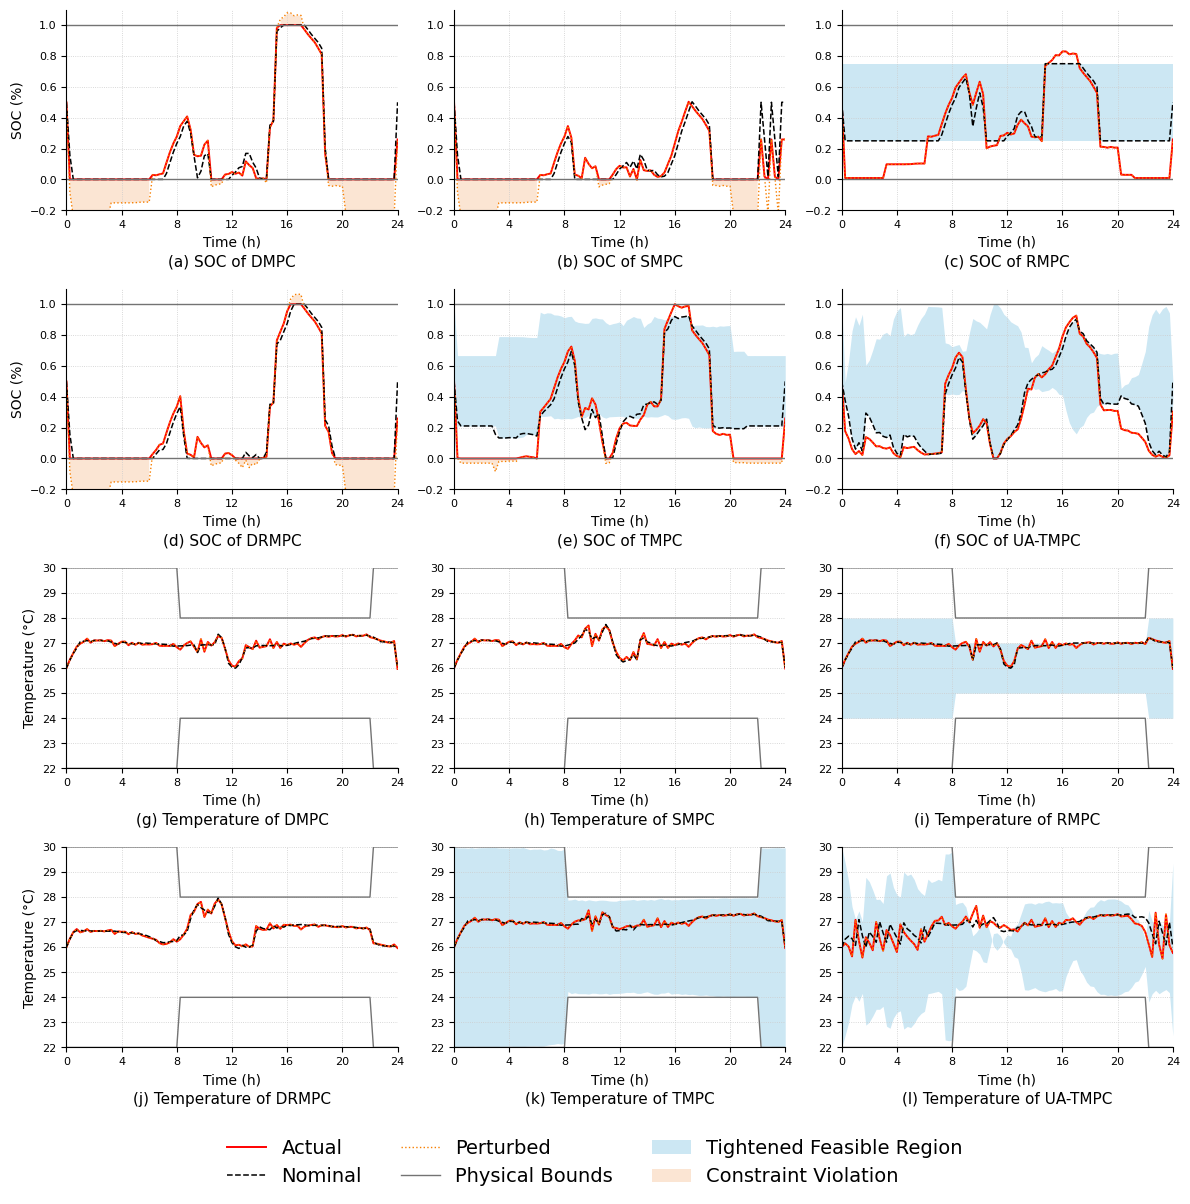

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/figures/daily_curve_07_09_ww_0.1.pdf')

In [8]:
robust_spare = 0.25
figures_dir = paths.root / "UATMPC" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)
pdf_figure_path = figures_dir / figure_path.with_suffix(".pdf").name


def scalar_series(values):
    return np.array([np.asarray(value, dtype=float).reshape(-1)[0] for value in values], dtype=float)


def physical_tau_bounds(n_points):
    lower = np.r_[params.tau_min[0], params.tau_min[: n_points - 1]]
    upper = np.r_[params.tau_max[0], params.tau_max[: n_points - 1]]
    return lower, upper


def draw_violation(ax, x, perturbed, lower, upper, color="#f4a261", alpha=0.28):
    high = perturbed > upper + 1e-9
    low = perturbed < lower - 1e-9
    if np.any(high):
        ax.fill_between(x, upper, perturbed, where=high, color=color, alpha=alpha, linewidth=0)
    if np.any(low):
        ax.fill_between(x, perturbed, lower, where=low, color=color, alpha=alpha, linewidth=0)


def robust_tightened_bounds(state_name, n_points):
    if state_name == "ess":
        lower = np.full(n_points, robust_spare)
        upper = np.full(n_points, 1.0 - robust_spare)
        return lower, upper

    physical_lower, physical_upper = physical_tau_bounds(n_points)
    margin = robust_spare * (physical_upper - physical_lower)
    return physical_lower + margin, physical_upper - margin


def plot_state_axis(ax, result, label, state_name):
    if result.get("status") != "ok":
        ax.text(0.5, 0.5, "failed", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    is_ess = state_name == "ess"
    actual_key = "ess_list" if is_ess else "tau_list"
    nominal_key = "nom_ess_list" if is_ess else "nom_tau_list"
    perturbed_key = "before_ess_list" if is_ess else "before_tau_list"
    lb_key = "ess_tube_lb" if is_ess else "tau_tube_lb"
    ub_key = "ess_tube_ub" if is_ess else "tau_tube_ub"

    scale = params.ess_max if is_ess else 1.0
    actual = scalar_series(result[actual_key]) / scale
    nominal = scalar_series(result[nominal_key]) / scale
    perturbed = scalar_series(result[perturbed_key]) / scale
    n_points = len(actual)
    x = np.arange(n_points) / 4

    if is_ess:
        lower = np.zeros(n_points)
        upper = np.ones(n_points)
        ax.set_ylim(-0.2, 1.1)
        ax.set_ylabel("SOC (%)")
    else:
        lower, upper = physical_tau_bounds(n_points)
        ax.set_ylim(22, 30)
        ax.set_ylabel("Temperature (°C)")

    if lb_key in result and ub_key in result:
        tube_lb = scalar_series(result[lb_key])[:n_points] / scale
        tube_ub = scalar_series(result[ub_key])[:n_points] / scale
        ax.fill_between(x[: len(tube_lb)], tube_lb, tube_ub, color="#8ecae6", alpha=0.45, linewidth=0)
    elif label == "RMPC":
        robust_lb, robust_ub = robust_tightened_bounds(state_name, n_points)
        ax.fill_between(x, robust_lb, robust_ub, color="#8ecae6", alpha=0.45, linewidth=0)

    draw_violation(ax, x, perturbed, lower, upper)
    ax.plot(x, actual, color="red", linewidth=1.4)
    ax.plot(x, nominal, color="black", linestyle="--", linewidth=1.1)
    ax.plot(x, perturbed, color="#f77f00", linestyle=":", linewidth=1.0)
    ax.plot(x, lower, color="0.45", linewidth=1.0)
    ax.plot(x, upper, color="0.45", linewidth=1.0)

    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 4))
    ax.set_xlabel("Time (h)")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, linestyle=":", linewidth=0.6, color="0.8")
    ax.tick_params(labelsize=8, labelbottom=True)


plot_labels = [label for label, _ in method_specs]
n_cols = 3
state_names = ["ess", "temperature"]
layout = [plot_labels[i : i + n_cols] for i in range(0, len(plot_labels), n_cols)]
n_layout_rows = len(layout)
n_rows = len(state_names) * n_layout_rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.1 * n_rows), sharex=False)
axes = np.asarray(axes).reshape(n_rows, n_cols)
letters = [chr(ord("a") + i) for i in range(n_rows * n_cols)]

for block_idx, state_name in enumerate(state_names):
    row_offset = block_idx * n_layout_rows
    for local_row, labels in enumerate(layout):
        for col in range(n_cols):
            ax = axes[row_offset + local_row, col]
            if col >= len(labels):
                ax.axis("off")
                continue
            label = labels[col]
            result = daily_results.get(label, {})
            plot_state_axis(ax, result, label, state_name)
            panel_idx = row_offset * n_cols + local_row * n_cols + col
            state_label = "SOC" if state_name == "ess" else "Temperature"
            ax.text(
                0.5,
                -0.22,
                f"({letters[panel_idx]}) {state_label} of {label}",
                ha="center",
                va="top",
                transform=ax.transAxes,
                fontsize=11,
            )
            if col > 0:
                ax.set_ylabel("")

legend_handles = [
    Line2D([0], [0], color="red", lw=1.4, label="Actual"),
    Line2D([0], [0], color="black", lw=1.1, ls="--", label="Nominal"),
    Line2D([0], [0], color="#f77f00", lw=1.0, ls=":", label="Perturbed"),
    Line2D([0], [0], color="0.45", lw=1.0, label="Physical Bounds"),
    Patch(facecolor="#8ecae6", edgecolor="none", alpha=0.45, label="Tightened Feasible Region"),
    Patch(facecolor="#f4a261", edgecolor="none", alpha=0.28, label="Constraint Violation"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.015), fontsize=14)
fig.tight_layout(rect=[0, 0.08, 1, 0.99], w_pad=0.9, h_pad=1)
fig.savefig(pdf_figure_path, format="pdf", bbox_inches="tight")
plt.show()

pdf_figure_path

## July 9 Operation Curves

Read the July 9 test-day data, build one-step-ahead point forecasts for load and PV, and plot the operation curves in a 2x2 layout.

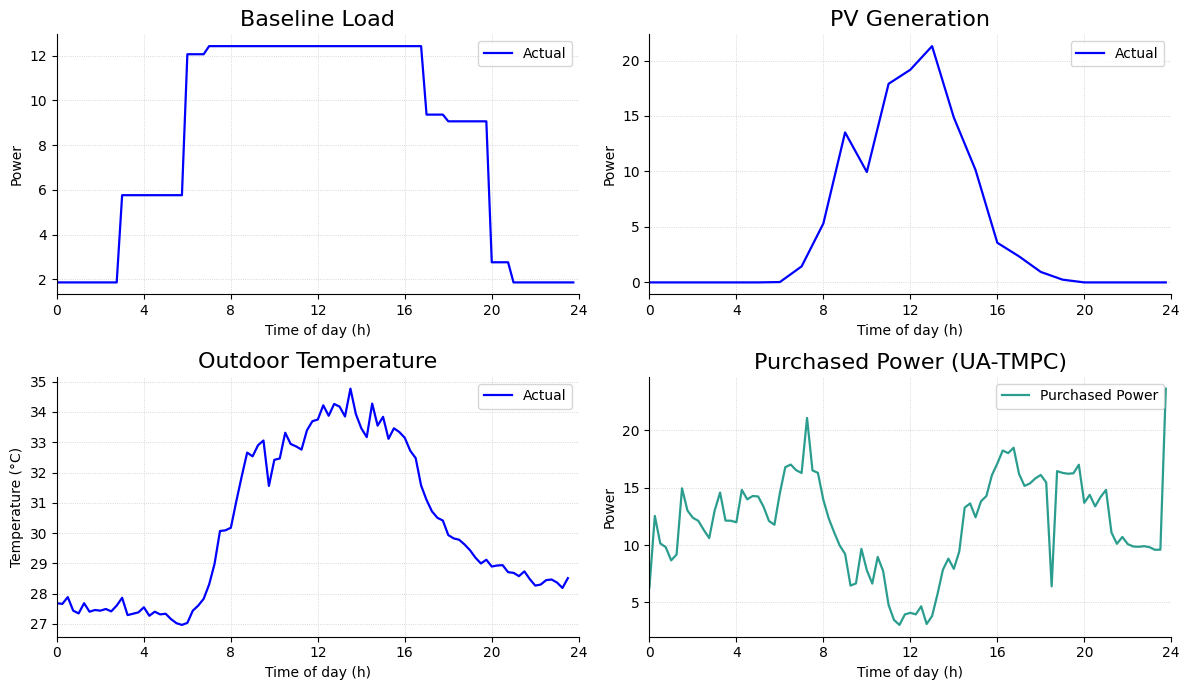

PosixPath('/Users/liqi/Desktop/UATMPC codes/UATMPC/results/daily_operation_curves_07_09_ua_tmpc.pdf')

In [10]:
from UATMPC.data import build_data_y_window, elec_price_read

plot_date = date
plot_ww = ww
plot_method_label = "UA-TMPC"
n_steps = 24 * 4
hours = np.arange(n_steps) / 4

case_data_79 = runner.build_case(plot_date)
selected_solar_79 = case_data_79["selected_solar"].reset_index(drop=True)
selected_load_79 = case_data_79["selected_load"].reset_index(drop=True)

actual_temperature = selected_solar_79["Temp"].iloc[-n_steps:].to_numpy(dtype=float)
actual_pv = selected_solar_79["generation"].iloc[-n_steps:].to_numpy(dtype=float)
actual_load = selected_load_79["load"].iloc[-n_steps:].to_numpy(dtype=float) / 5e3

quantiles = config.quantiles
horizon = config.control_horizon


def scalar_value(value):
    return float(np.asarray(value).reshape(-1)[0])


def run_ua_tmpc_power_profile(date, ww_value, force_rerun=False):
    power_cache = paths.results_dir / f"daily_operation_{date[0]:02d}_{date[1]:02d}_ua_tmpc_ww_{ww_value:g}.pkl"
    if power_cache.exists() and not force_rerun:
        with power_cache.open("rb") as f:
            return pickle.load(f)

    params = runner.physical_params
    case_data = runner.build_case(date)
    real_temp, real_net_load = build_data_y_window(
        date[0],
        date[1],
        runner.data["solar_data"],
        runner.data["load_data"],
    )
    real_temp = np.asarray(real_temp, dtype=float).reshape(-1)
    real_net_load = np.asarray(real_net_load, dtype=float).reshape(-1)
    price_data = elec_price_read(date[0], date[1], runner.data["da_price"], runner.data["rt_price"])
    c_buy, c_cur, c_pen = price_data

    state = runner._initial_day_state()
    p_buy_list = []
    nominal_p_buy_list = []

    for curr_t in range(n_steps):
        result = runner.optimizers["ua_tube"].solve_soft_tube(
            case_data,
            price_data,
            curr_t,
            state["curr_ess"],
            state["curr_tau"],
            ww=float(ww_value),
        )
        forecasts, controls, alphs, ther_ps, ther_taus, ess_ps, ess_esss = result
        forecast_net_load, forecast_tau = forecasts
        p_buy, _ = controls
        alph_buy, alph_hvac, alph_ess, _ = alphs
        _, nom_p_heat, nom_p_cool, _, _ = ther_ps
        nom_tau, _, _ = ther_taus
        _, nom_p_ch, nom_p_dis, _, _ = ess_ps
        nom_ess, _, _ = ess_esss

        elec_error = (real_net_load[curr_t] - forecast_net_load) * params.www
        tau_error = (real_temp[curr_t] - forecast_tau) * params.www
        hvac_error = alph_hvac * elec_error
        hvac_temp_effect = runner._hvac_error_temp_effect(
            hvac_error,
            nom_p_heat,
            nom_p_cool,
            state["curr_tau"],
        )
        curr_tau = (
            state["curr_tau"]
            + params.gama1 * (forecast_tau - state["curr_tau"])
            + params.thermal_power_effect(nom_p_heat, nom_p_cool)
            + tau_error * params.gama1
            + hvac_temp_effect
        )
        ess_error = elec_error / params.eta_dch if elec_error < 0 else elec_error * params.eta_ch
        curr_ess = (
            state["curr_ess"]
            + params.eta_ch * nom_p_ch
            - nom_p_dis / params.eta_dch
            + alph_ess * ess_error
        )
        curr_p_buy = p_buy + alph_buy * elec_error

        p_buy_list.append(scalar_value(curr_p_buy))
        nominal_p_buy_list.append(scalar_value(p_buy))

        curr_ess, curr_tau, _ = runner._apply_state_correction(curr_ess, curr_tau, c_cur, c_pen, curr_t)
        state["curr_ess"] = curr_ess
        state["curr_tau"] = curr_tau
        state["ess_list"].append(curr_ess)
        state["tau_list"].append(curr_tau)
        state["nom_ess_list"].append(nom_ess)
        state["nom_tau_list"].append(nom_tau)

    power_profile = {
        "date": date,
        "method": "soft_ua_tube",
        "ww": ww_value,
        "p_buy_list": np.asarray(p_buy_list, dtype=float),
        "nominal_p_buy_list": np.asarray(nominal_p_buy_list, dtype=float),
    }
    with power_cache.open("wb") as f:
        pickle.dump(power_profile, f)
    return power_profile

power_profile_79 = run_ua_tmpc_power_profile(plot_date, plot_ww)
p_buy_79 = np.asarray(power_profile_79["p_buy_list"], dtype=float).reshape(-1)[:n_steps]

temperature_hours = hours[:-1]
actual_temperature_aligned = actual_temperature[:-1]

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
(ax_load, ax_pv), (ax_temp, ax_buy) = axes

ax_load.plot(hours, actual_load, color="blue", linewidth=1.6, label="Actual")
ax_load.set_title("Baseline Load", fontsize=16)
ax_load.set_ylabel("Power")
ax_load.set_xlabel("Time of day (h)")
ax_load.tick_params(labelbottom=True)
ax_load.legend()

ax_pv.plot(hours, actual_pv, color="blue", linewidth=1.6, label="Actual")
ax_pv.set_title("PV Generation", fontsize=16)
ax_pv.set_ylabel("Power")
ax_pv.set_xlabel("Time of day (h)")
ax_pv.tick_params(labelbottom=True)
ax_pv.legend()

ax_temp.plot(temperature_hours, actual_temperature_aligned, color="blue", linewidth=1.6, label="Actual")
ax_temp.set_title(f"Outdoor Temperature", fontsize=16)
ax_temp.set_ylabel("Temperature (°C)")
ax_temp.set_xlabel("Time of day (h)")
ax_temp.legend()

ax_buy.plot(hours[: len(p_buy_79)], p_buy_79, color="#2a9d8f", linewidth=1.6, label="Purchased Power")
ax_buy.set_title(f"Purchased Power ({plot_method_label})", fontsize=16)
ax_buy.set_ylabel("Power")
ax_buy.set_xlabel("Time of day (h)")
ax_buy.legend()

for ax in axes.ravel():
    ax.set_xlim(0, 24)
    ax.set_xticks(np.arange(0, 25, 4))
    ax.grid(True, linestyle=":", linewidth=0.6, color="0.8")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# fig.suptitle("July 9 Test-Day Operation Curves", y=1.02, fontsize=14)
fig.tight_layout()
operation_figure_path = paths.results_dir / f"daily_operation_curves_{plot_date[0]:02d}_{plot_date[1]:02d}_{plot_method_label.lower().replace('-', '_')}.pdf"
fig.savefig(operation_figure_path, format="pdf", bbox_inches="tight")
plt.show()

operation_figure_path